In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv(r'C:\Users\DELL\Desktop\fraud-detection\data\creditcard.csv')

print(df.shape)
print(df.dtypes)
print(df.isnull().sum())

counts= df['Class'].value_counts()
fraud_pct= counts[1]/len(df) * 100
print(f"Fraud: {counts[1]} ({fraud_pct:.3f}%)")
print(f"Legit: {counts[0]}")

print(df[['Amount', 'Time']].describe())

(284807, 31)
Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64
Fraud: 492 (0.173%)
Legit: 284

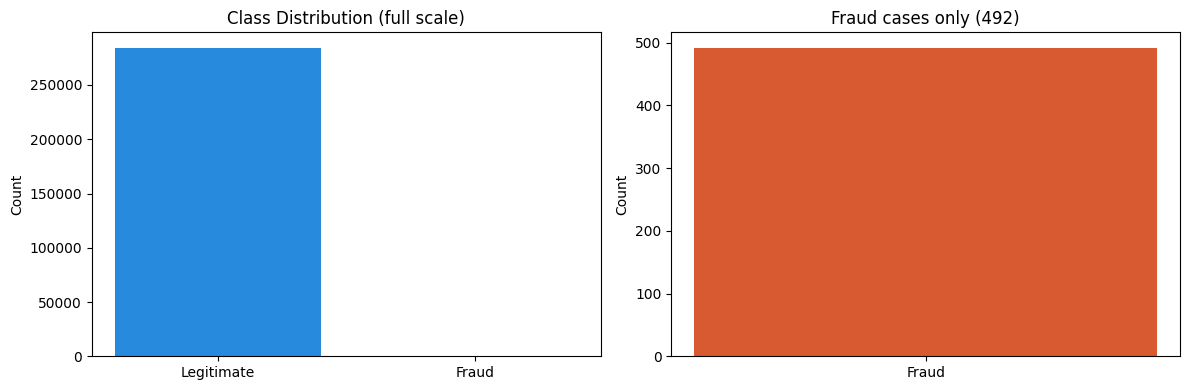

Fraud rate: 0.1727%
Class ratio: 1 fraud per 577 legit


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes= plt.subplots(1,2, figsize=(12,4))

counts=df['Class'].value_counts()
axes[0].bar(['Legitimate', 'Fraud'], counts.values, color=['#278ADD', '#D85A30'])
axes[0].set_title("Class Distribution (full scale)")
axes[0].set_ylabel('Count')

axes[1].bar(['Fraud'], [counts[1]], color='#D85A30')
axes[1].set_title("Fraud cases only (492)")
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

print(f"Fraud rate: {counts[1]/len(df)*100:.4f}%")
print(f"Class ratio: 1 fraud per {counts[0]//counts[1]} legit")

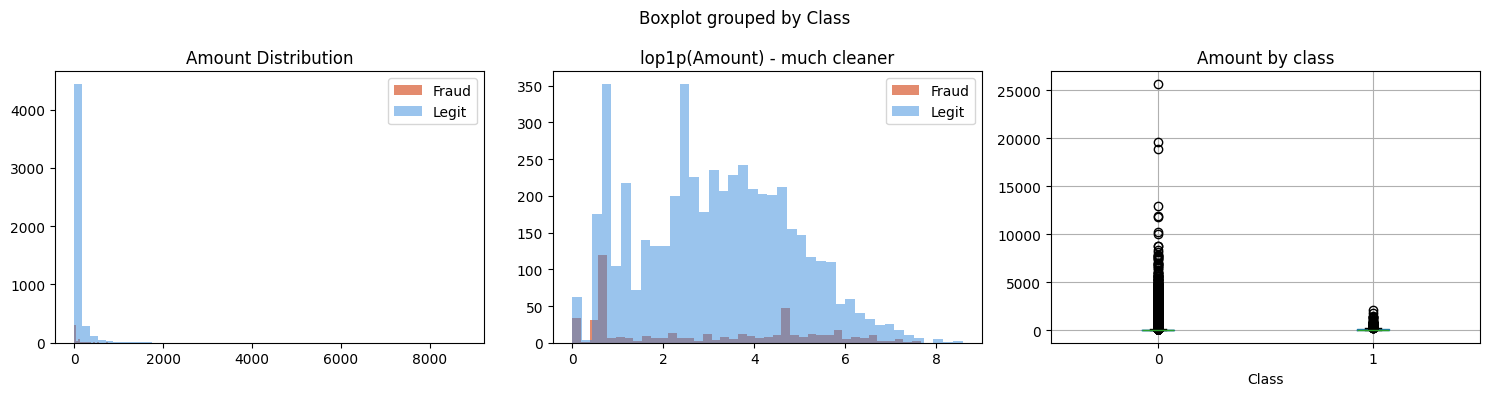

Fraud amount stats: count     492.000000
mean      122.211321
std       256.683288
min         0.000000
25%         1.000000
50%         9.250000
75%       105.890000
max      2125.870000
Name: Amount, dtype: float64
Legit amount stats: count    284315.000000
mean         88.291022
std         250.105092
min           0.000000
25%           5.650000
50%          22.000000
75%          77.050000
max       25691.160000
Name: Amount, dtype: float64


In [4]:
fraud= df[df['Class']==1]
legit= df[df['Class']==0]

fig,axes= plt.subplots(1,3, figsize=(15,4))

axes[0].hist(fraud['Amount'], bins=50, color='#D85A30', alpha=0.7, label='Fraud')
axes[0].hist(legit['Amount'].sample(5000), bins=50, color='#378ADD', alpha=0.5, label='Legit')
axes[0].set_title('Amount Distribution')
axes[0].legend()

axes[1].hist(np.log1p(fraud['Amount']), bins=40, color='#D85A30', alpha=0.7, label='Fraud')
axes[1].hist(np.log1p(legit['Amount'].sample(5000)), bins=40, color='#378ADD', alpha=0.5, label='Legit')
axes[1].set_title('lop1p(Amount) - much cleaner')
axes[1].legend()

df.boxplot(column='Amount', by='Class', ax=axes[2])
axes[2].set_title('Amount by class')

plt.tight_layout()
plt.show()

print('Fraud amount stats:', fraud['Amount'].describe())
print('Legit amount stats:', legit['Amount'].describe())

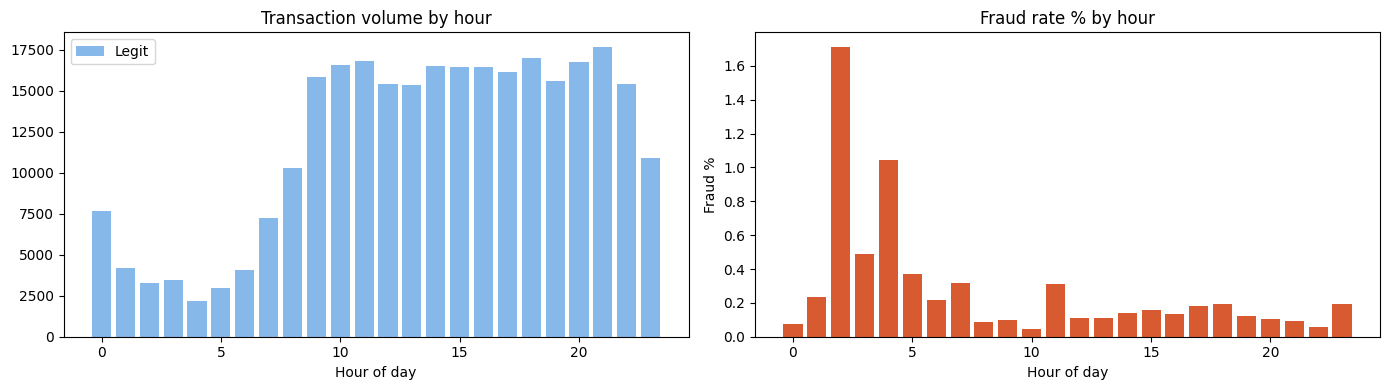

In [5]:
df['hour']= (df['Time']%86400) // 3600

fig, axes=plt.subplots(1,2, figsize=(14,4))

legit_h= df[df['Class']==0].groupby('hour').size()
fraud_h= df[df['Class']==1].groupby('hour').size()

axes[0].bar(legit_h.index, legit_h.values, color='#378ADD', alpha=0.6, label='Legit')
axes[0].set_title('Transaction volume by hour')
axes[0].set_xlabel('Hour of day')
axes[0].legend()

fraud_rate_h= fraud_h / (fraud_h + legit_h) * 100
axes[1].bar(fraud_rate_h.index, fraud_rate_h.values, color='#D85A30')
axes[1].set_title('Fraud rate % by hour')
axes[1].set_xlabel('Hour of day')
axes[1].set_ylabel('Fraud %')

plt.tight_layout()
plt.show()

     Legit_mean  Fraud_mean      diff
V3     0.012171   -7.033281  7.045452
V14    0.012064   -6.971723  6.983787
V17    0.011535   -6.665836  6.677371
V12    0.010832   -6.259393  6.270225
V10    0.009824   -5.676883  5.686707
V7     0.009637   -5.568731  5.578368
V1     0.008258   -4.771948  4.780206
V4    -0.007860    4.542029  4.549889
V16    0.007164   -4.139946  4.147110
V11   -0.006576    3.800173  3.806749


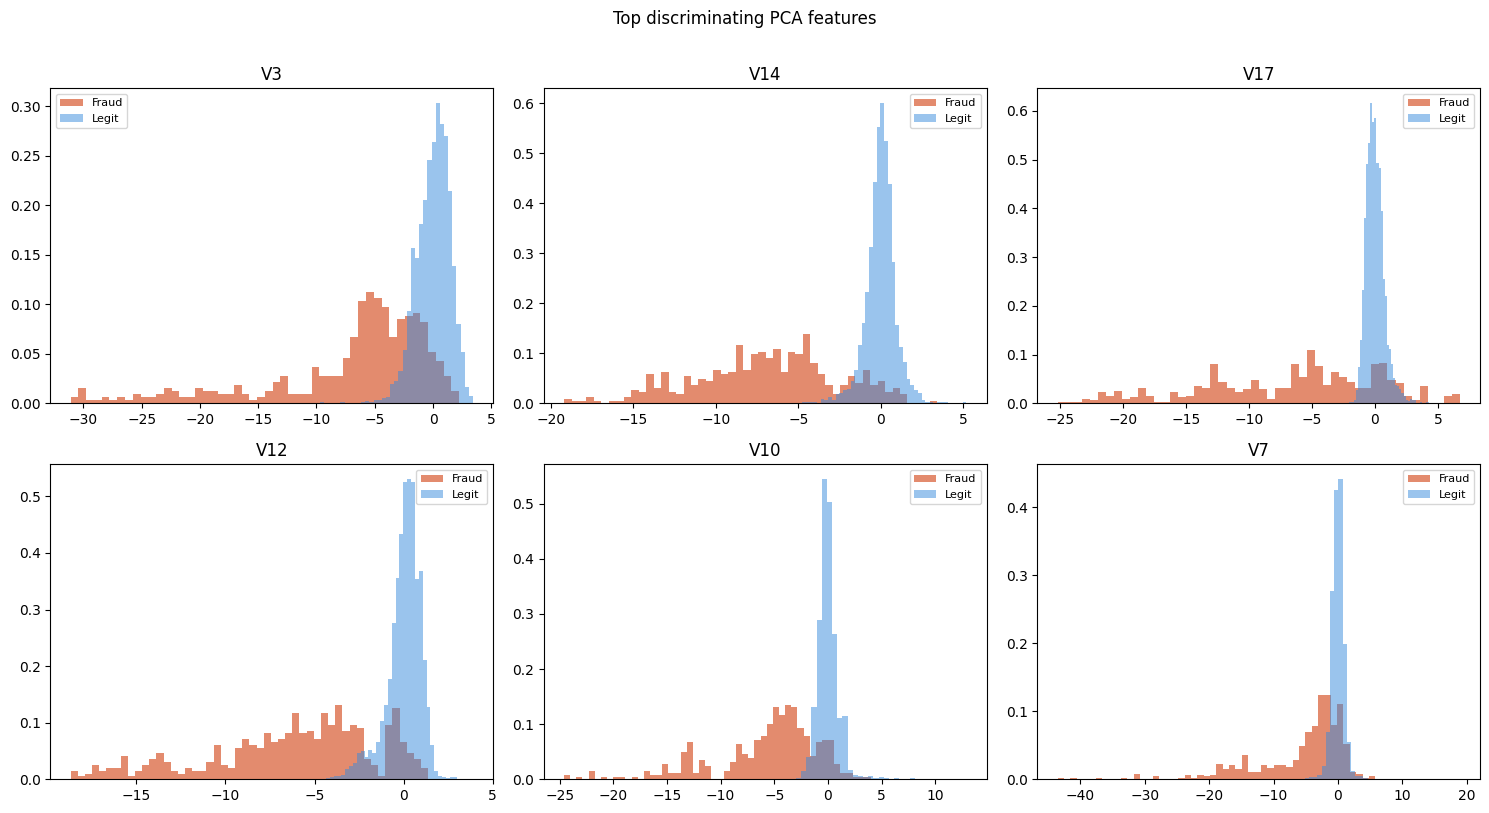

In [7]:
v_cols= [f'V{i}' for i in range(1,29)]
means= df.groupby('Class')[v_cols].mean().T
means.columns= ['Legit_mean', 'Fraud_mean']
means['diff']= abs(means['Fraud_mean'] - means['Legit_mean'])
means_sorted = means.sort_values('diff', ascending=False)
print(means_sorted.head(10))

top_feats=  means_sorted.head(6).index.to_list()
fig, axes= plt.subplots(2, 3, figsize=(15,8))

for ax, feat in zip(axes.flatten(), top_feats):
    ax.hist(fraud[feat], bins=50, color='#D85A30', alpha=0.7, density=True, label='Fraud')
    ax.hist(legit[feat].sample(5000), bins=50, color='#378ADD', alpha=0.5, density=True, label='Legit')
    ax.set_title(feat)
    ax.legend(fontsize=8)

plt.suptitle('Top discriminating PCA features', y=1.01)
plt.tight_layout()
plt.show()

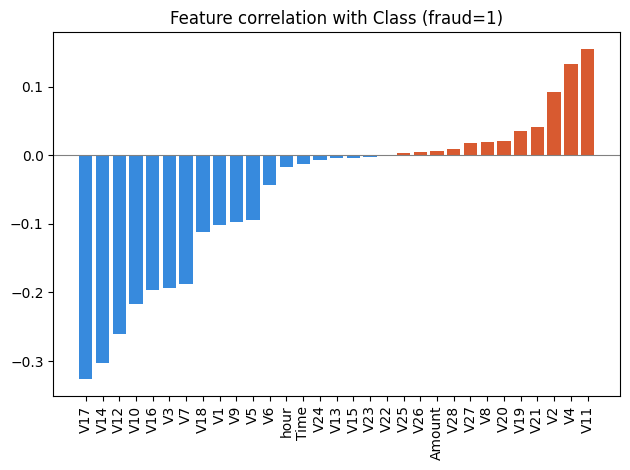

Top negative correlations (fraud indicators):
V17   -0.326481
V14   -0.302544
V12   -0.260593
V10   -0.216883
V16   -0.196539
Name: Class, dtype: float64
Top positive correlations:
V19    0.034783
V21    0.040413
V2     0.091289
V4     0.133447
V11    0.154876
Name: Class, dtype: float64


In [8]:
corr_with_class= df.corr()['Class'].drop('Class').sort_values()

plt.Figure(figsize=(10,5))
colors= ['#D85A30' if c>0 else '#378ADD' for c in corr_with_class]
plt.bar(corr_with_class.index, corr_with_class.values, color=colors)
plt.xticks(rotation=90)
plt.title('Feature correlation with Class (fraud=1)')
plt.axhline(0, color='grey', linewidth=0.8)
plt.tight_layout()
plt.show()

print('Top negative correlations (fraud indicators):')
print(corr_with_class.head(5))
print('Top positive correlations:')
print(corr_with_class.tail(5))

## EDA Summary - Key Findings

1. **Class imbance** 492 fraud / 284,315 legit (0.172%)
   -> Ratio 1:577. Must use SMOTE + AUPRC metric, not accuracy.

2. **Amount:** Fraud median ~$9.25, not large transactions.
   -> lop1p(Amount) needed. Raw Amout is right-skewed.

3. **Time:** Fraud peaks at 2-4am when legit volume is low.
   -> hour_of_day is useful engineered feature.

4. **Top features:** V14, V17, V12, V10 best separate classes.
   -> V14 alone shows dramatic distribution difference

5. **Correlations:** V17/V14/V12 negatively correlated with fraud, V4/V11 positively. V1-V28 unrelated with each other (PCA).

Next step: Feature Engineering